In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\ShieldNet-AI\data/raw/cic_aligned_training.csv")
df.head()


,Flow Duration,Total Fwd Packets,Total Bwd Packets,Total Length Fwd,Fwd Packet Max,Idle Mean,Label
0,4,2,0,12,6,0.0,Benign
1,1,2,0,12,6,0.0,Benign
2,3,2,0,12,6,0.0,Benign
3,1,2,0,12,6,0.0,Benign
4,609,7,4,484,233,0.0,Benign


In [16]:
df["Label"].value_counts()


Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

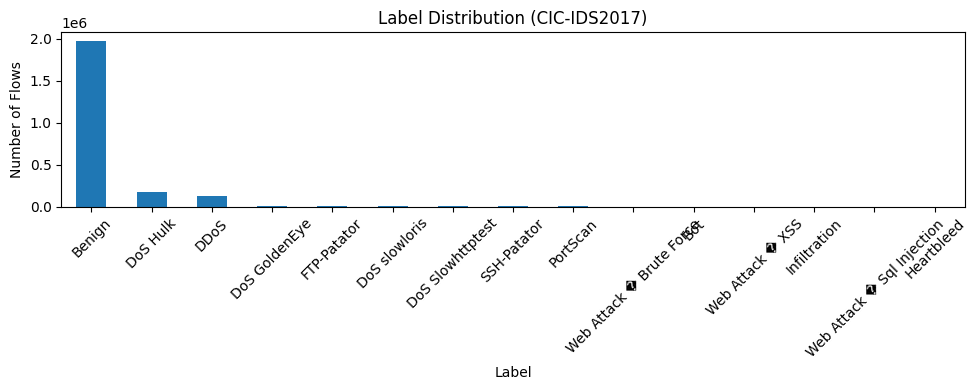

In [3]:
plt.figure(figsize=(10,4))
df["Label"].value_counts().plot(kind="bar")
plt.title("Label Distribution (CIC-IDS2017)")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [25]:
df["BinaryLabel"] = (
    df["Label"]
    .str.strip()
    .str.lower()
    .apply(lambda x: "Benign" if x == "benign" else "Attack")
)
df["BinaryLabel"].value_counts()


BinaryLabel
Benign    1977318
Attack     336492
Name: count, dtype: int64

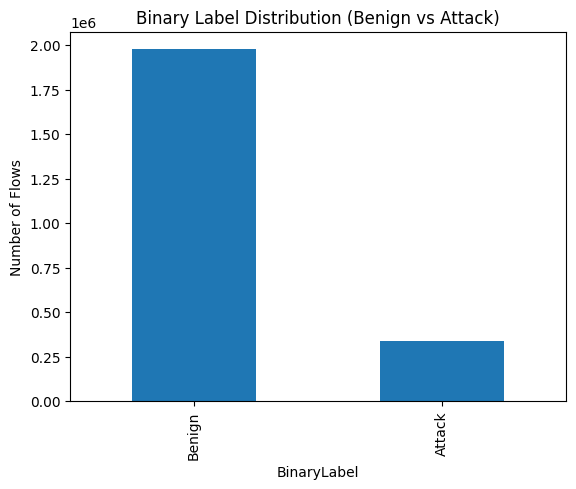

In [26]:
df["BinaryLabel"].value_counts().plot(kind="bar")
plt.title("Binary Label Distribution (Benign vs Attack)")
plt.ylabel("Number of Flows")
plt.show()


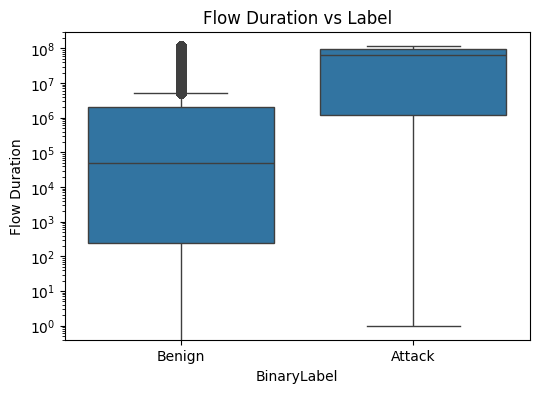

In [ ]:
# Flow Duraion - Shows attack flows often have abnormal durations.

plt.figure(figsize=(6,4))
sns.boxplot(x="BinaryLabel", y="Flow Duration", data=df)
plt.yscale("log")
plt.title("Flow Duration vs Label")
plt.show()


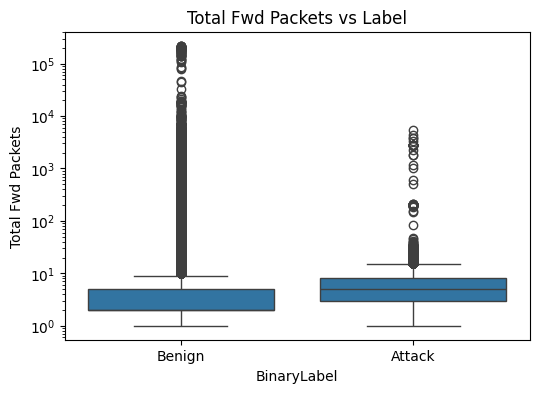

In [28]:
# Total Fwd Packets - Attacks usually generate asymmetric packet counts.

plt.figure(figsize=(6,4)) 
sns.boxplot(x="BinaryLabel", y="Total Fwd Packets", data=df)
plt.yscale("log")
plt.title("Total Fwd Packets vs Label")
plt.show()

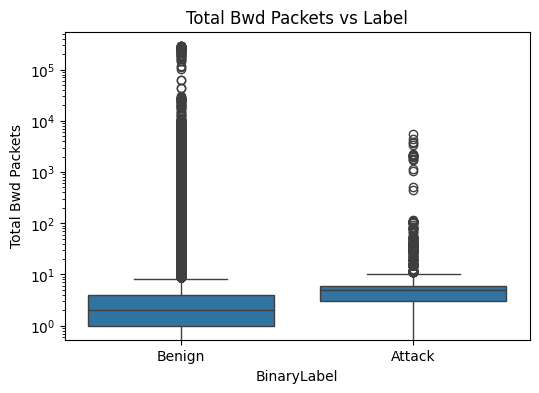

In [29]:
# Total Bwd Packets - Clear separation in scans, floods, bot traffic.

plt.figure(figsize=(6,4))
sns.boxplot(x="BinaryLabel", y="Total Bwd Packets", data=df)
plt.yscale("log")
plt.title("Total Bwd Packets vs Label")
plt.show()

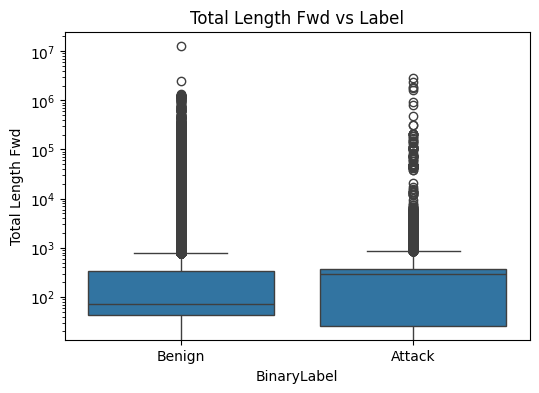

In [30]:
# Total Length Fwd - Payload-heavy vs control-heavy attacks.

plt.figure(figsize=(6,4))
sns.boxplot(x="BinaryLabel", y="Total Length Fwd", data=df)
plt.yscale("log")
plt.title("Total Length Fwd vs Label")
plt.show()

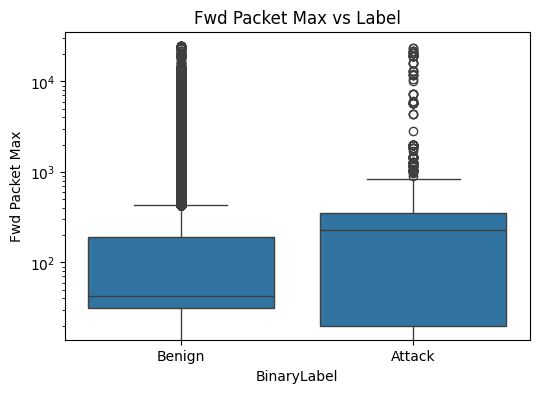

In [31]:
# Fwd Packet Max - Large packets often signal exploits or floods.

plt.figure(figsize=(6,4))
sns.boxplot(x="BinaryLabel", y="Fwd Packet Max", data=df)
plt.yscale("log")
plt.title("Fwd Packet Max vs Label")
plt.show()

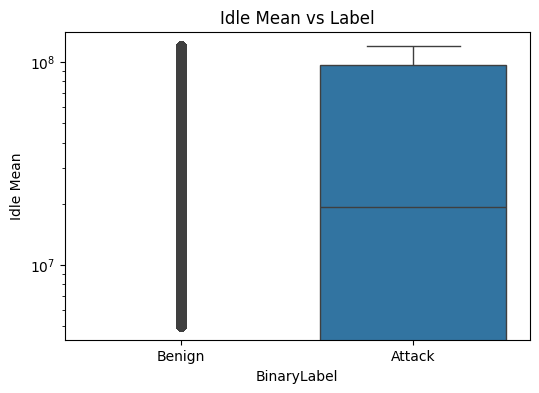

In [32]:
# Idle Mean - Idle behavior is very discriminative for botnets.

plt.figure(figsize=(6,4))
sns.boxplot(x="BinaryLabel", y="Idle Mean", data=df)
plt.yscale("log")
plt.title("Idle Mean vs Label")
plt.show()

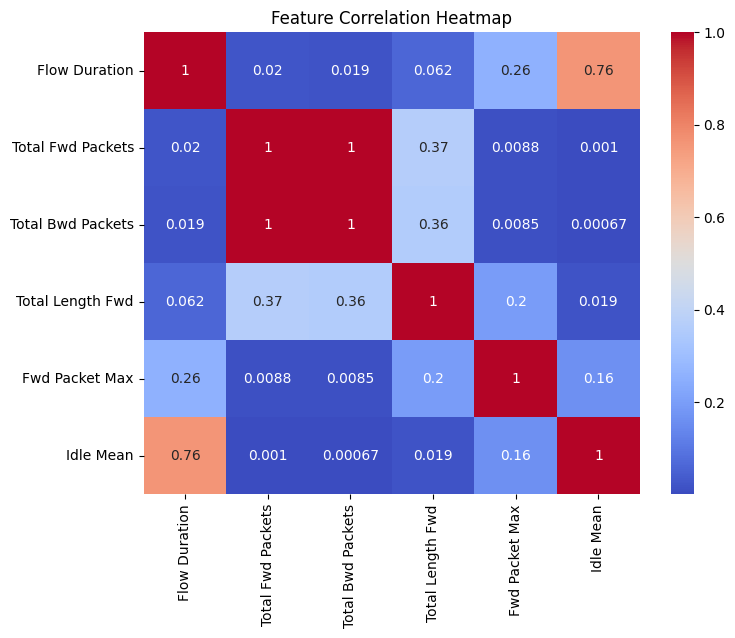

In [ ]:
# Correlation sanity check - Shows features are related but not duplicates.

plt.figure(figsize=(8,6))
sns.heatmap(
    df.drop(columns=["Label","BinaryLabel"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()